In [ ]:
"""
Exercise 4: NumPy Array Operations
Complete the following tasks using NumPy.
"""

# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0

import numpy as np

matrix = np.ones((5,5))
matrix[1:4, 1:4] = 0
print(matrix)


# Task 2: Normalize a random array
# (5 points)
np.random.seed(42)
random_data = np.random.randn(100, 3)   #randn(standard normal distribution with values centered around 0 ranging from -1 to +1  but could possibly extend beyond)
# TODO: Normalize each column to have mean=0 and std=1
normalized_data = (random_data - np.mean(random_data, axis=0)) / np.std(random_data, axis=0)



# Task 3: Implement linear regression solution using normal equation
# (10 points)
# Given X (features) and y (target), compute theta
# theta = (X^T X)^(-1) X^T y
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1
# TODO: Calculate theta_hat using the normal equation
theta_est = np.linalg.inv(X.T @ X) @ X.T @ y    #@ used to multiply 2 matrrices
# TODO: Print the estimated coefficients and compare with true_theta
print("True coef: ",true_theta)
print("Estmated coef ",theta_est)


In [ ]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)


# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan


# Task 1: Data Cleaning and Exploration (10 points)

# TODO: Display basic information about the dataset
print("First 5 rows: \n", df.head())
print("Last 5 rows: \n", df.tail())
print("Statistical Summary: \n", df.describe())
print(df.info())
print("Dataset shape: ", df.shape)

# TODO: Identify and count missing values
df.isna().sum()

# TODO: Fill missing exam_score with the mean score for the student's major
major_mean = df.groupby('major')['exam_score'].mean()
df['exam_score'] = df['exam_score'].fillna(major_mean)

# TODO: Fill missing hours_studied with the median for the student's year
year_median = df.groupby('year')['hours_studied'].median()
df['hours_studied'] = df['hours_studied'].fillna(year_median)



# Task 2: Analysis (10 points)

# TODO: Calculate and display the average exam_score by major
print("Avg exam score by major: \n", df.groupby('major')['exam_score'].mean())

# TODO: Find the major with the highest average exam_score
print("Major with highest avg exam score: ", df.groupby('major')['exam_score'].mean().idxmax()) #idmax() returns the index(in this case major) of the maxavg exam score

# TODO: Calculate the correlation between hours_studied and exam_score
print("Correlation b/w hours studied and exam score: ",df['hours_studied'].corr(df['exam_score']))

# TODO: Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)


df["Performance"] = np.where(df["exam_score"] > 90, "Excellent",
               np.where(df["exam_score"] >= 80, "Good",
                  np.where(df["exam_score"] >= 70, "Average", "Needs Improvement")))

print(df[['exam_score', 'Performance']])


In [ ]:
'''EX 5 CONTINUATION'''

# Task 3: Advanced Analysis (10 points)


# TODO: For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied

data = df.groupby(['major', 'year']).agg({
    'student_id': 'count',
    'exam_score': 'mean',
    'hours_studied': 'mean'
})
print(data)

# TODO: Identify top 5 students based on exam_score (handle ties appropriately)
df.sort_values('exam_score', ascending = False).head(5)

# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns)
pd.pivot_table(df, values='exam_score', index='major', columns='year', aggfunc='mean')

In [ ]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

import matplotlib.pyplot as plt
import seaborn as sns

# Continue using the df from Exercise 5

# Task 1: Distribution Visualization (8 points)
# TODO: Create a figure with 2 subplots side by side
#       Left: Histogram of exam scores with KDE overlay
#       Right: Box plot of exam scores by major
# TODO: Add appropriate titles, labels, and styling

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  #1row , 2 cols

# Histogram
axes[0].hist(df['exam_score'], bins=10, edgecolor='black', color = "yellow")
axes[0].set_title('Exam Score Distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')

# Boxplot by major
df.boxplot(column='exam_score', by='major', ax=axes[1], color = 'red')
axes[1].set_title('Scores by Major')
axes[1].set_xlabel('Major')
axes[1].set_ylabel('Score')
plt.show()

# Task 2: Relationship Visualization (8 points)
# TODO: Create a scatter plot of hours_studied vs exam_score
# TODO: Color points by major
# TODO: Add a regression line
# TODO: Include appropriate legends, titles, and axis labels

plt.figure(figsize=(8,6))

for major, group in df.groupby("major"):
    plt.scatter(
        group["hours_studied"],
        group["exam_score"],
        label=major
    )

    sns.regplot(
    data=df,
    x="hours_studied",
    y="exam_score",
    scatter=False,
    color="black"
)

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")
plt.legend(title="Major")
plt.show()




/tmp/ipykernel_25355/2615769354.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Performance', y='exam_score', data=df, palette='Set2', ax=axes[1, 1])


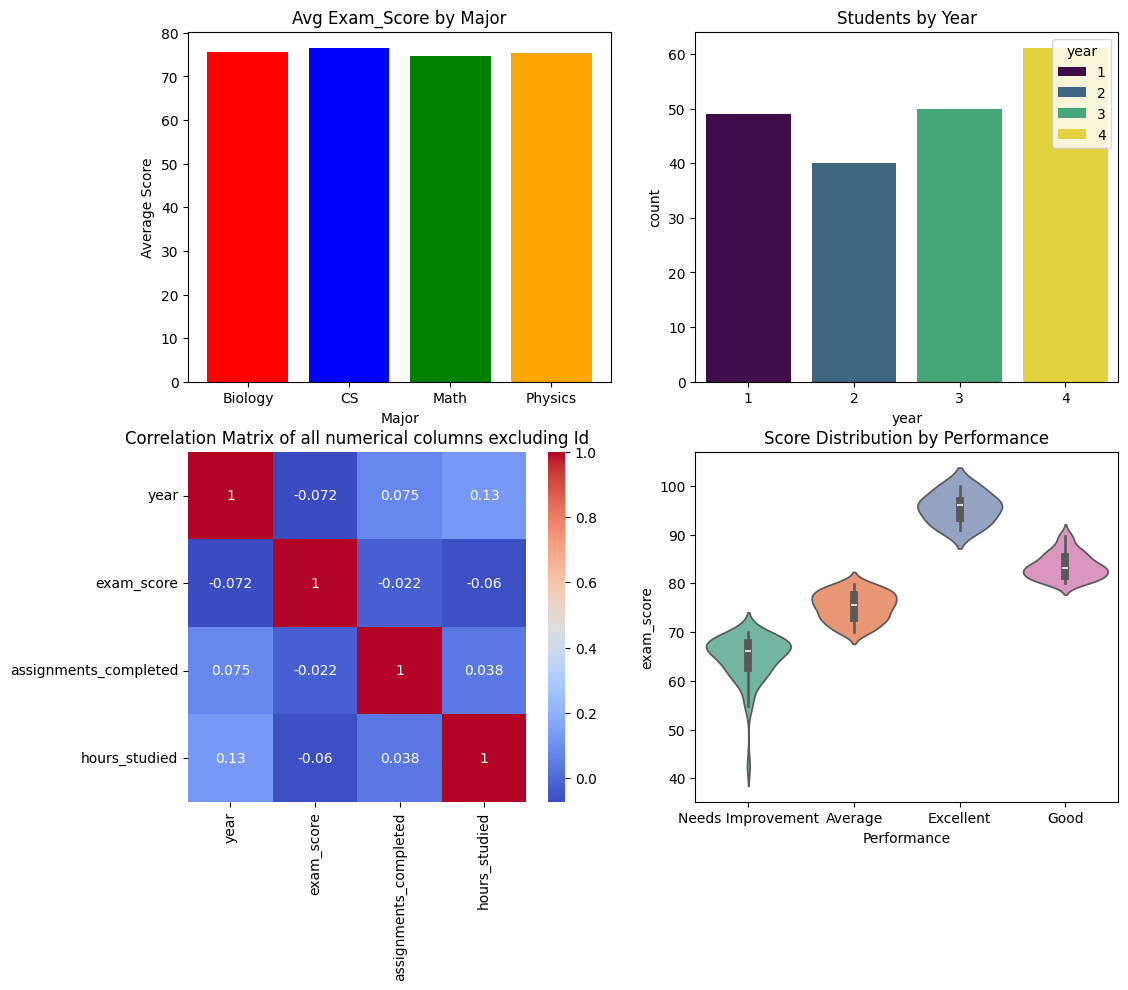

In [25]:
# Task 3: Advanced Dashboard (9 points)
# TODO: Create a 2x2 subplot figure containing:
#       1. Bar chart: Average exam score by major
#       2. Count plot: Number of students by year
#       3. Heat map: Correlation matrix of numerical columns
#       4. Violin plot: Exam score distribution by performance category
# TODO: Adjust layout, add titles, and ensure readability

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#Bar chart: Avg exam score by major (colored)
avg_major = df.groupby('major')['exam_score'].mean()
colors = ['red', 'blue', 'green', 'orange']
axes[0, 0].bar(avg_major.index, avg_major.values, color=colors)
axes[0, 0].set_title('Avg Exam_Score by Major')
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Average Score')

#Count plot: students by year (colored by year)
sns.countplot(x='year', data=df, hue='year', palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('Students by Year')

#Heatmap: correlation matrix
corr = df.select_dtypes(include='number').drop(columns = ['student_id']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title('Correlation Matrix of all numerical columns excluding Id')


#Violin plot: exam score by performance
sns.violinplot(x='Performance', y='exam_score', data=df, palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Score Distribution by Performance')

plt.show()

In [ ]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# TODO: Calculate customer lifetime value (CLV)
#       CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#       where churn_risk = 1 - (purchase_frequency / max_frequency)

# max frequency
max_freq = customers['purchase_frequency'].max()

# churn risk
churn_risk = 1 - (customers['purchase_frequency'] / max_freq)

#CLV
customers['CLV'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + churn_risk)


# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70

bins = [18, 25, 35, 50, 70]
labels = ['18-25', '26-35', '36-50', '51-70']

customers['age_group'] = pd.cut(customers['age'], bins=bins, labels=labels, include_lowest=True)

# TODO: For each age group, calculate:
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total CLV
age_stats = customers.groupby('age_group', observed=True).agg(
    avg_income=('income', 'mean'),
    avg_clv=('CLV', 'mean'),
    total_clv=('CLV', 'sum')
)
age_stats['num_customers'] = customers.groupby('age_group',observed=True).size()
print(age_stats)


# TODO: Identify top 10% of customers by CLV

ninety_percentile = customers['CLV'].quantile(0.9)

top_10_percent_customers = customers[customers['CLV'] >= ninety_percentile]

print(top_10_percent_customers)




/tmp/ipykernel_25355/3701955283.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ageGroup, group in customers.groupby("age_group"):
/tmp/ipykernel_25355/3701955283.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_clv = customers.groupby('age_group')['CLV'].mean()


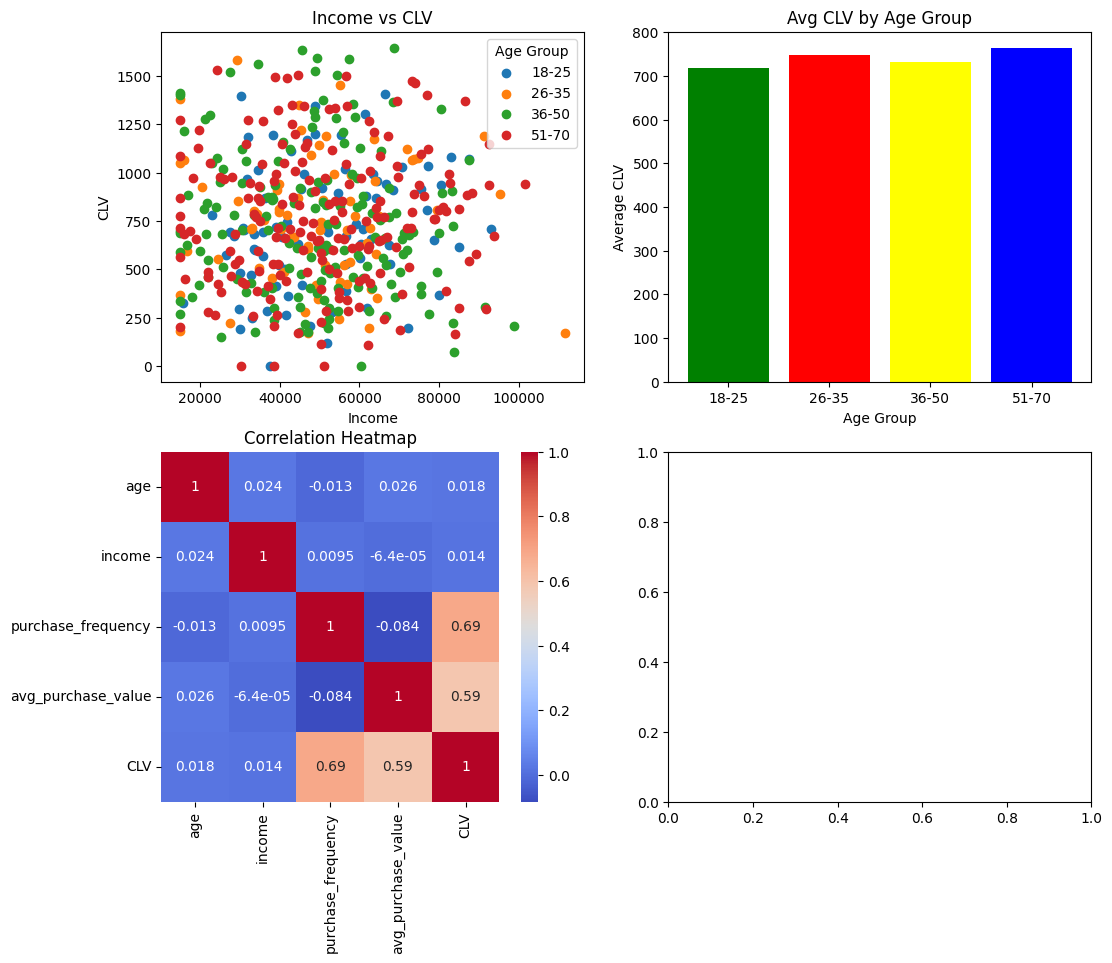

In [52]:

# TODO: Create visualizations:
#       1. Scatter plot of income vs CLV (color by age group)
#       2. Bar chart of average CLV by age group
#       3. Correlation heatmap

# TODO: Write a brief analysis paragraph (as a markdown cell)
#       summarizing key findings and recommendations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#Scatter plot
for ageGroup, group in customers.groupby("age_group"):
    axes[0, 0].scatter(
        group["income"],
        group["CLV"],
        label=ageGroup
    )

axes[0, 0].set_xlabel("Income")
axes[0, 0].set_ylabel("CLV")
axes[0, 0].set_title("Income vs CLV")
axes[0, 0].legend(title="Age Group")

#barplot
avg_clv = customers.groupby('age_group')['CLV'].mean()
colors = ['green', 'red', 'yellow', 'blue']

axes[0, 1].bar(avg_clv.index, avg_clv.values, color=colors)

axes[0, 1].set_xlabel('Age Group')
axes[0, 1].set_ylabel('Average CLV')
axes[0, 1].set_title('Avg CLV by Age Group')


# Correlation heatmap
corr = customers.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title('Correlation Heatmap')

plt.show()

# TODO: Write a brief analysis paragraph (as a markdown cell)
#       summarizing key findings and recommendations

## Summary

From the correlation heatmap, **purchase_frequency** and **avg_purchase_value** have the strongest relationship with **CLV**.
This means customers who shop more often and spend more per visit are
likely to be more valuable to the business in the long run.
therefore focusing on loyalty programs and promotions that encourage
customers to visit more often and spend more will be vital for the growth of the business.

From the scatter plot, there is no clear pattern between **income**
and **CLV**. The dots are spread randomly with no direction. This means a customer earning more money does not necessarily spend more.
So using income is mot the best way to identify the best customers.

From the **bar chart**, the 51–70 age group has the highest average
CLV and the 18–25 age group has the lowest. This suggests older
customers tend to be more committed and consistent buyers.